Load EEG Data

In [ ]:
import mne

file_path = "data\\S001\\S001R01.edf"

raw = mne.io.read_raw_edf(file_path, preload=True)

print(raw.info)

Extracting EDF parameters from S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5., Fc3., Fc1., Fcz., Fc2., Fc4., Fc6., C5.., C3.., C1.., ...
 chs: 64 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: 2009-08-12 16:15:00 UTC
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>


Plotting Raw EEG Signal (multiple channels)

Using matplotlib as 2D backend.


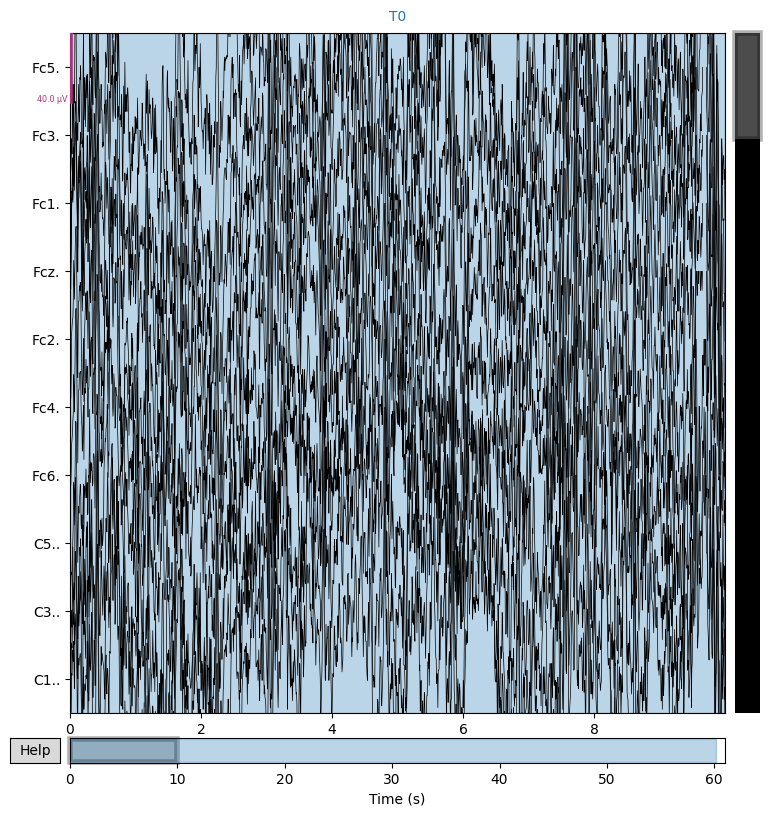

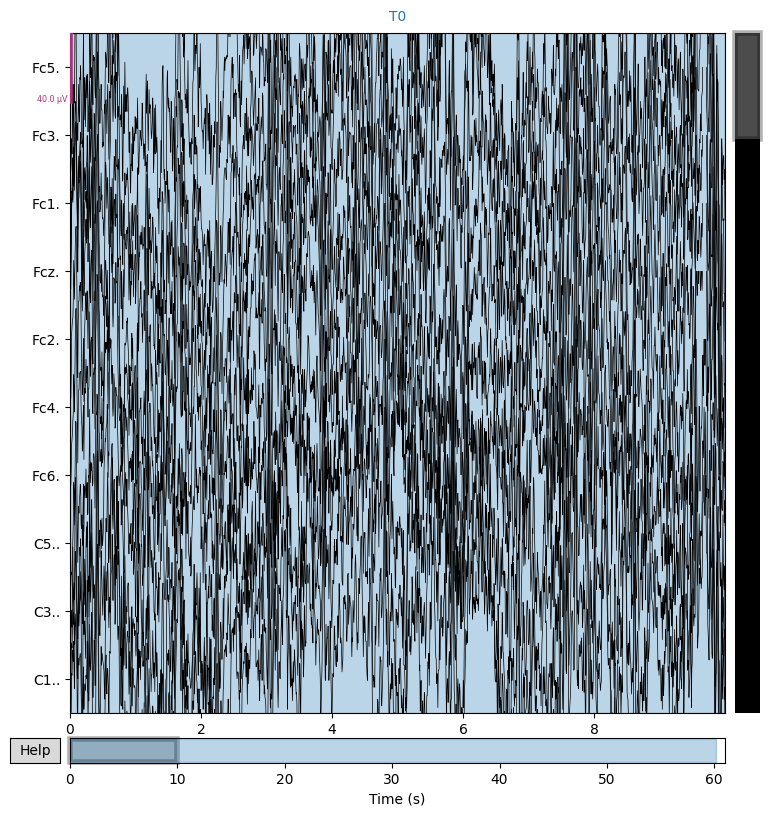

In [2]:
raw.plot(duration=10, n_channels=10)

Normalization:

Make signal scale consistent

Formula:
(signal - mean) / standard deviation

All channels are normalized independently

In [3]:
import numpy as np

data, times = raw.get_data(return_times=True)

data_norm = (data - np.mean(data, axis=1, keepdims=True)) / np.std(data, axis=1, keepdims=True)

Extract One Channel for DSP Analysis

In [4]:
signal = data_norm[0]   # first EEG channel

Plotting One Channel of the Normalized Raw Signal

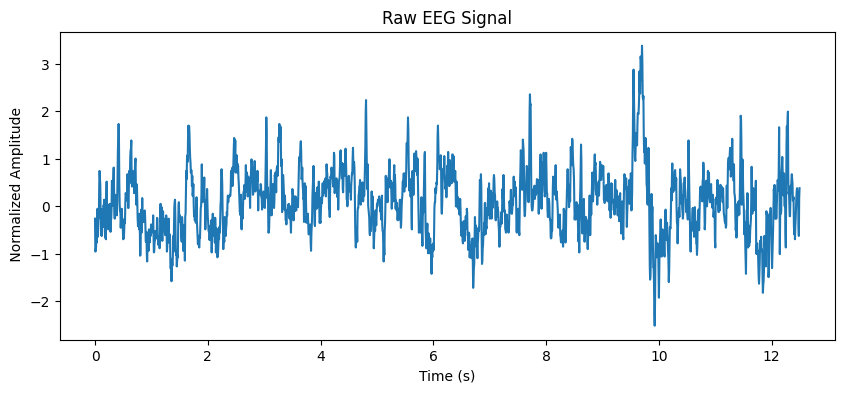

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(times[:2000], signal[:2000])
plt.title("Raw EEG Signal")
plt.xlabel("Time (s)")
plt.ylabel(" Normalized Amplitude")
plt.show()

Low-Pass Filter :
Removes high-frequency noise.

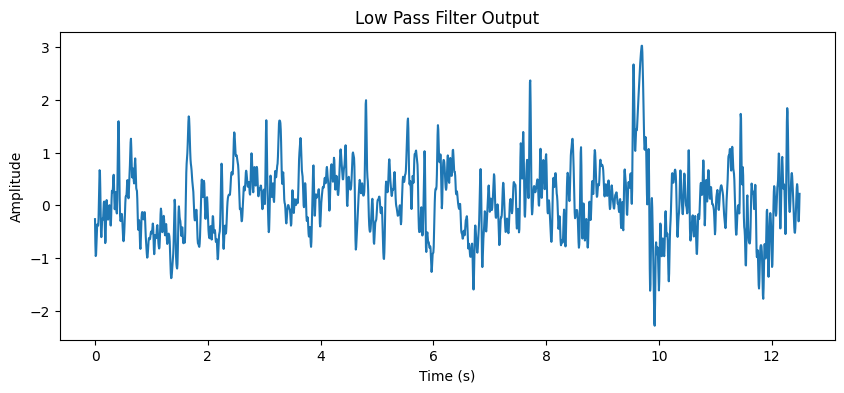

In [6]:
from scipy.signal import butter, filtfilt, iirnotch
fs = int(raw.info['sfreq'])  # 160 Hz

cutoff = 30 # Hz
b, a = butter(4, cutoff/(fs/2), btype='low')
lowpass = filtfilt(b, a, signal)

plt.figure(figsize=(10,4))
plt.plot(times[:2000], lowpass[:2000])
plt.title("Low Pass Filter Output")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

High-Pass Filter : Removes baseline drift and slow artifacts.

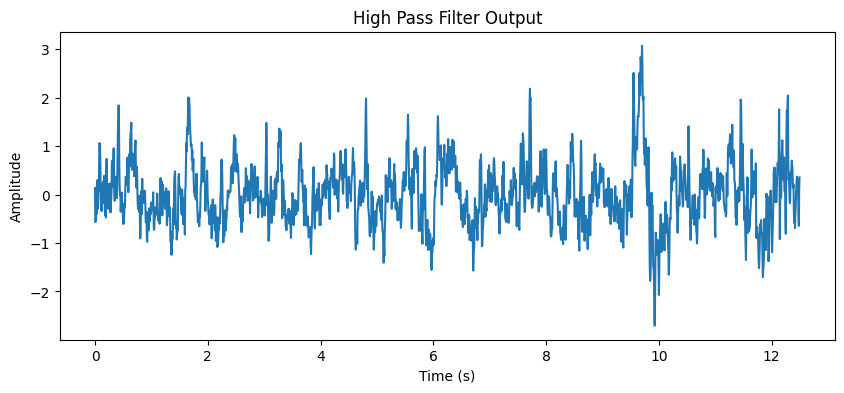

In [7]:
cutoff = 0.5
b, a = butter(4, cutoff/(fs/2), btype='high')
highpass = filtfilt(b, a, signal)

plt.figure(figsize=(10,4))
plt.plot(times[:2000], highpass[:2000])
plt.title("High Pass Filter Output")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Band-Pass Filter:

Typical EEG band: 8–30 Hz

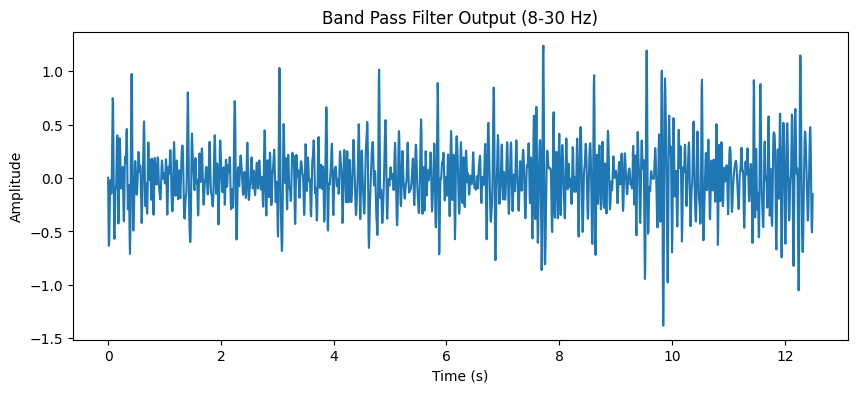

In [8]:
low = 8
high = 30

b, a = butter(4, [low/(fs/2), high/(fs/2)], btype='band')
bandpass = filtfilt(b, a, signal)

plt.figure(figsize=(10,4))
plt.plot(times[:2000], bandpass[:2000])
plt.title("Band Pass Filter Output (8-30 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Notch Filter:

Removes 50 Hz interference.

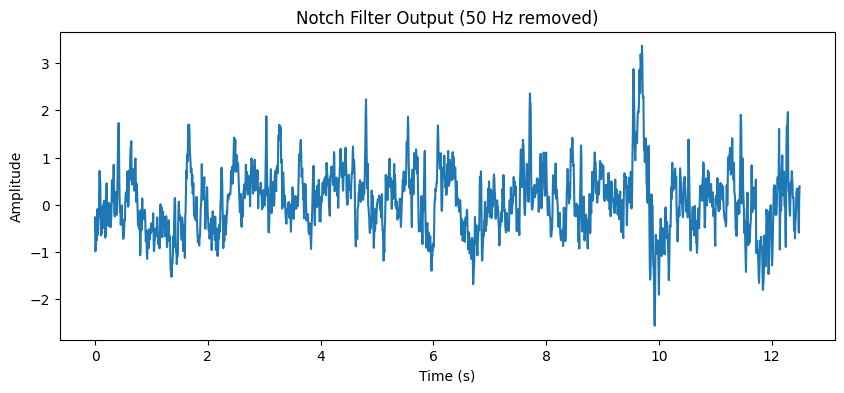

In [9]:
f0 = 50
Q = 30

b, a = iirnotch(f0, Q, fs)
notch = filtfilt(b, a, signal)

plt.figure(figsize=(10,4))
plt.plot(times[:2000], notch[:2000])
plt.title("Notch Filter Output (50 Hz removed)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

Plot All Filters Together (for Comparison)

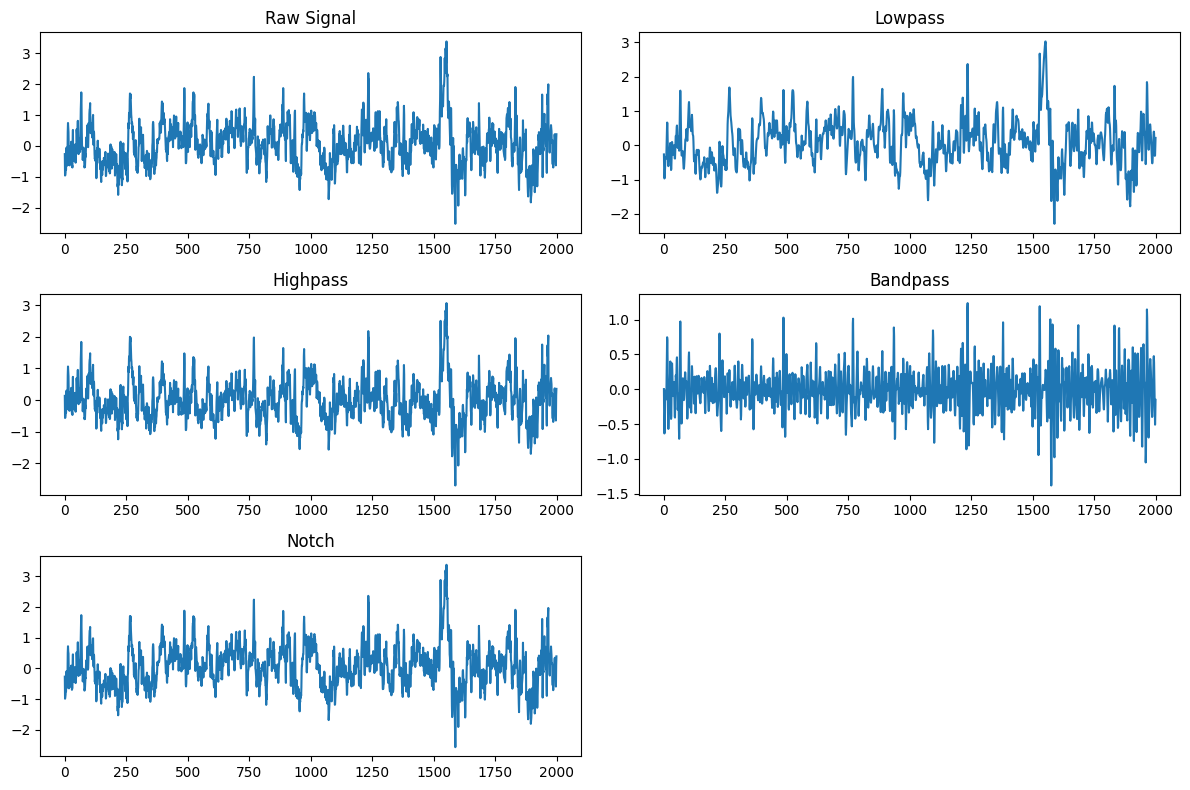

In [10]:
plt.figure(figsize=(12,8))

plt.subplot(3,2,1)
plt.plot(signal[:2000])
plt.title("Raw Signal")

plt.subplot(3,2,2)
plt.plot(lowpass[:2000])
plt.title("Lowpass")

plt.subplot(3,2,3)
plt.plot(highpass[:2000])
plt.title("Highpass")

plt.subplot(3,2,4)
plt.plot(bandpass[:2000])
plt.title("Bandpass")

plt.subplot(3,2,5)
plt.plot(notch[:2000])
plt.title("Notch")

plt.tight_layout()
plt.show()

Deciding Best Filter

Choose filter with:

Low variance (noise removed)

Low Standard Deviation (Stable signal)

In [11]:
def compute_metrics(signal):
    variance = np.var(signal)
    std = np.std(signal)
    return variance, std

results = {
    "lowpass": compute_metrics(lowpass),
    "highpass": compute_metrics(highpass),
    "bandpass": compute_metrics(bandpass),
    "notch": compute_metrics(notch)
}

for k, (var, std) in results.items():
    print(f"{k}: Variance={var:.4f}, Standard Deviation={std:.4f}")

lowpass: Variance=0.9700, Standard Deviation=0.9849
highpass: Variance=0.5639, Standard Deviation=0.7510
bandpass: Variance=0.0905, Standard Deviation=0.3008
notch: Variance=0.9978, Standard Deviation=0.9989


Bandpass → Best balance

We will use the bandpass-filtered signal since it is most suitable for EEG signal preprocessing as it has least Variance meaning least noise and also it contains Alpha + Beta bands.

Feature Extraction:

Defining the signal we use

In [12]:
signal_processed = bandpass

FFT (Fast Fourier Transform):

Convert signal from time domain → frequency domain

Identify dominant EEG frequencies

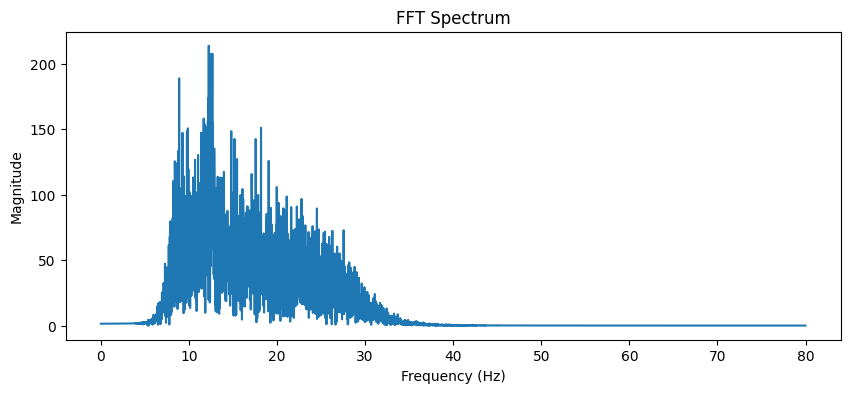

In [13]:
from scipy.fft import fft, fftfreq

N = len(signal_processed)

yf = fft(signal_processed)
xf = fftfreq(N, 1/fs)

plt.figure(figsize=(10,4))
plt.plot(xf[:N//2], np.abs(yf[:N//2]))
plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()

Spectrogram:

Shows how frequency changes over time

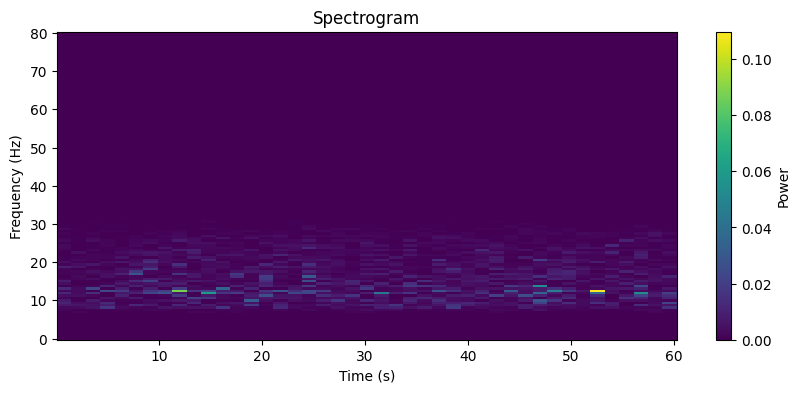

In [14]:
from scipy.signal import spectrogram

f, t, Sxx = spectrogram(signal_processed, fs)

plt.figure(figsize=(10,4))
plt.pcolormesh(t, f, Sxx)
plt.title("Spectrogram")
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar(label="Power")
plt.show()

Wavelet Transform:

Analyze both time and frequency simultaneously.

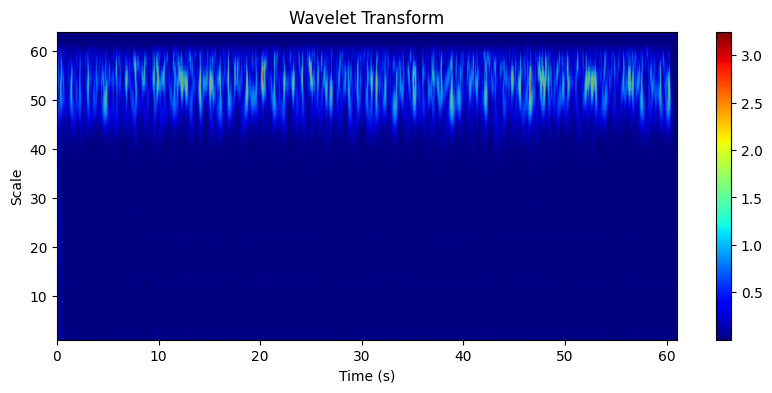

In [15]:
import pywt

scales = np.arange(1,64)

coefficients, frequencies = pywt.cwt(signal_processed, scales, 'morl', 1/fs)

plt.figure(figsize=(10,4))
plt.imshow(abs(coefficients), aspect='auto', cmap='jet',
           extent=[0, len(signal_processed)/fs, 1, 64])

plt.title("Wavelet Transform")
plt.xlabel("Time (s)")
plt.ylabel("Scale")
plt.colorbar()
plt.show()

FFT:
Shows frequency content, 
No time localization

Spectrogram:
Time-frequency analysis, 
Fixed resolution

Scalogram (Wavelet Image): Scalogram is a visual representation of wavelet coefficients, converting time-frequency information into a 2D image.

Wavelet Transform → Coefficient matrix → Scalogram (image)

Multi-resolution analysis,
Captures transient changes, 
Suitable for non-stationary EEG signals 

Conclusion:
Wavelet Transform is selected and the input to the CNN is Scalogram (image)